In [4]:
!pip install catboost & lightgbm

/bin/bash: line 1: lightgbm: command not found


In [13]:
import numpy as np
import pandas as pd

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import gc
from scipy.stats import rankdata

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, roc_curve

In [6]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train)

            id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  \
0            0   58    1                4  152          239             0   
1            1   52    1                1  125          325             0   
2            2   56    0                2  160          188             0   
3            3   44    0                3  134          229             0   
4            4   58    1                4  140          234             0   
...        ...  ...  ...              ...  ...          ...           ...   
629995  629995   56    0                1  110          226             0   
629996  629996   54    1                4  128          249             1   
629997  629997   67    1                4  130          275             0   
629998  629998   52    1                4  140          199             0   
629999  629999   51    0                2  130          199             0   

        EKG results  Max HR  Exercise angina  ST depression  Slope of ST  \

In [7]:
def feature_engineering(df):
  df_news = df.copy()

  df_news['HR_Ratio'] = df_news['Max HR'] / (220 - df_news['Age'] + 1e-5)
  df_news['RPP'] = df['BP'] * df_news['Max HR']
  df_news['BP_Age_Combination'] = df_news['Age'] * df_news['BP']
  df_news['Cholesterol_to_BP'] = df_news['Cholesterol'] / df_news['BP'] + 1e-5

  conditions_age = [
    (df['Age'] >= 20) & (df['Age'] <= 39),
    (df['Age'] >= 40) & (df['Age'] <= 59),
    (df['Age'] >= 60)
  ]

  conditions_bp = [
      (df['BP'] < 120),
      (df['BP'] >= 120) & (df['BP'] <= 129),
      (df['BP'] >= 130)
  ]

  choices = [0, 1, 2]

  df_news['Age_bins'] = np.select(conditions_age, choices)

  df_news['Is_ST_Depressed'] = (df_news['ST depression'] > 0).astype(int)
  df_news['Is_Thallium_wrong'] = (df_news['Thallium'] > 3).astype(int)

  df_news['BP_category'] = np.select(conditions_bp, choices)

  df_news['Thallium'] = df_news['Thallium'].map(df_news['Thallium'].value_counts(normalize=True))

  return df_news

In [8]:
train_fe = feature_engineering(train)
test_fe = feature_engineering(test)

print(train_fe)

            id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  \
0            0   58    1                4  152          239             0   
1            1   52    1                1  125          325             0   
2            2   56    0                2  160          188             0   
3            3   44    0                3  134          229             0   
4            4   58    1                4  140          234             0   
...        ...  ...  ...              ...  ...          ...           ...   
629995  629995   56    0                1  110          226             0   
629996  629996   54    1                4  128          249             1   
629997  629997   67    1                4  130          275             0   
629998  629998   52    1                4  140          199             0   
629999  629999   51    0                2  130          199             0   

        EKG results  Max HR  Exercise angina  ...  Thallium  Heart Disease 

In [9]:
category_OneHot = ['Chest pain type', 'EKG results', 'Sex']
category_Scaler = ['RPP', 'BP_Age_Combination', 'Cholesterol_to_BP', 'Max HR', 'Age', 'BP']

OneHot = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
scaler = StandardScaler()

data_encoder_train = OneHot.fit_transform(train_fe[category_OneHot])
data_encoder_test = OneHot.transform(test_fe[category_OneHot])

encoded_train = pd.DataFrame(data_encoder_train, columns=OneHot.get_feature_names_out(category_OneHot), index=train_fe.index)
encoded_test = pd.DataFrame(data_encoder_test, columns=OneHot.get_feature_names_out(category_OneHot), index=test_fe.index)

train_fe = train_fe.drop(columns=category_OneHot)
test_fe = test_fe.drop(columns=category_OneHot)

train_fe = pd.concat([train_fe, encoded_train], axis=1)
test_fe = pd.concat([test_fe, encoded_test], axis=1)

train_fe[category_Scaler] = scaler.fit_transform(train_fe[category_Scaler])
test_fe[category_Scaler] = scaler.transform(test_fe[category_Scaler])

In [10]:
X_test = test_fe

X_train = train_fe.drop(columns='Heart Disease')
y_train = (train_fe['Heart Disease'] != 'Absence').astype(int)

In [11]:
cat_params = {
    "iterations": 2000,
    "learning_rate": 0.03,
    "depth": 4,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "bootstrap_type": "Bernoulli",
    "subsample": 0.8,
    "random_strength": 1.0,
    "task_type": "GPU", # Change to "CPU" if running without a GPU
    "verbose": False
}

xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "learning_rate": 0.02,
    "max_depth": 4,
    "subsample": 0.85,
    "colsample_bytree": 0.8,
    "n_estimators": 2500,
    "tree_method": "hist",
    "device": "cuda", # Change to "cpu" if running without GPU
    "random_state": 42,
    "n_jobs": -1
}

lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.02,
    "num_leaves": 31,
    "max_depth": 4,
    "subsample": 0.8,
    "colsample_bytree": 0.7,
    "n_estimators": 2500,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1
}

In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_cb = np.zeros(len(X_train))
oof_xgb = np.zeros(len(X_train))
oof_lgb = np.zeros(len(X_train))

test_cb = np.zeros(len(X_test))
test_xgb = np.zeros(len(X_test))
test_lgb = np.zeros(len(X_test))

# To store feature importances for visualization later
lgb_importances = np.zeros(X_train.shape[1])

for fold, (tr, val) in enumerate(skf.split(X_train, y_train)):
    print(f"\n--- Fold {fold+1} ---")

    # CatBoost
    cb = CatBoostClassifier(**cat_params, random_seed=42+fold)
    cb.fit(X_train.iloc[tr], y_train[tr], eval_set=(X_train.iloc[val], y_train[val]), early_stopping_rounds=150, verbose=False)
    oof_cb[val] = cb.predict_proba(X_train.iloc[val])[:,1]
    test_cb += cb.predict_proba(X_test)[:,1] / skf.n_splits
    print(f"CatBoost AUC: {roc_auc_score(y_train[val], oof_cb[val]):.5f}")

    # XGBoost
    xgb = XGBClassifier(**xgb_params)
    xgb.fit(X_train.iloc[tr], y_train[tr], eval_set=[(X_train.iloc[val], y_train[val])], verbose=False)
    oof_xgb[val] = xgb.predict_proba(X_train.iloc[val])[:,1]
    test_xgb += xgb.predict_proba(X_test)[:,1] / skf.n_splits
    print(f"XGBoost  AUC: {roc_auc_score(y_train[val], oof_xgb[val]):.5f}")

    # LightGBM
    lgb = LGBMClassifier(**lgb_params)
    lgb.fit(X_train.iloc[tr], y_train[tr], eval_set=[(X_train.iloc[val], y_train[val])])
    oof_lgb[val] = lgb.predict_proba(X_train.iloc[val])[:,1]
    test_lgb += lgb.predict_proba(X_test)[:,1] / skf.n_splits
    lgb_importances += lgb.feature_importances_ / skf.n_splits
    print(f"LightGBM AUC: {roc_auc_score(y_train[val], oof_lgb[val]):.5f}")

    gc.collect()

print("\n--- Out-of-Fold AUCs ---")
print(f"CatBoost OOF AUC: {roc_auc_score(y_train, oof_cb):.5f}")
print(f"XGBoost  OOF AUC: {roc_auc_score(y_train, oof_xgb):.5f}")
print(f"LightGBM OOF AUC: {roc_auc_score(y_train, oof_lgb):.5f}")


--- Fold 1 ---


Default metric period is 5 because AUC is/are not implemented for GPU


CatBoost AUC: 0.95573
XGBoost  AUC: 0.95571
LightGBM AUC: 0.95569

--- Fold 2 ---


Default metric period is 5 because AUC is/are not implemented for GPU


CatBoost AUC: 0.95467
XGBoost  AUC: 0.95467
LightGBM AUC: 0.95462

--- Fold 3 ---


...

CatBoost AUC: 0.95548
XGBoost  AUC: 0.95548
LightGBM AUC: 0.95544

--- Fold 4 ---


Default metric period is 5 because AUC is/are not implemented for GPU


CatBoost AUC: 0.95503
XGBoost  AUC: 0.95502
LightGBM AUC: 0.95502

--- Fold 5 ---


Default metric period is 5 because AUC is/are not implemented for GPU


CatBoost AUC: 0.95585
XGBoost  AUC: 0.95585
LightGBM AUC: 0.95583

--- Out-of-Fold AUCs ---
CatBoost OOF AUC: 0.95535
XGBoost  OOF AUC: 0.95534
LightGBM OOF AUC: 0.95532


/tmp/ipykernel_609/4029737424.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances_df, x='Importance', y='Feature', ax=ax[0], palette='viridis')


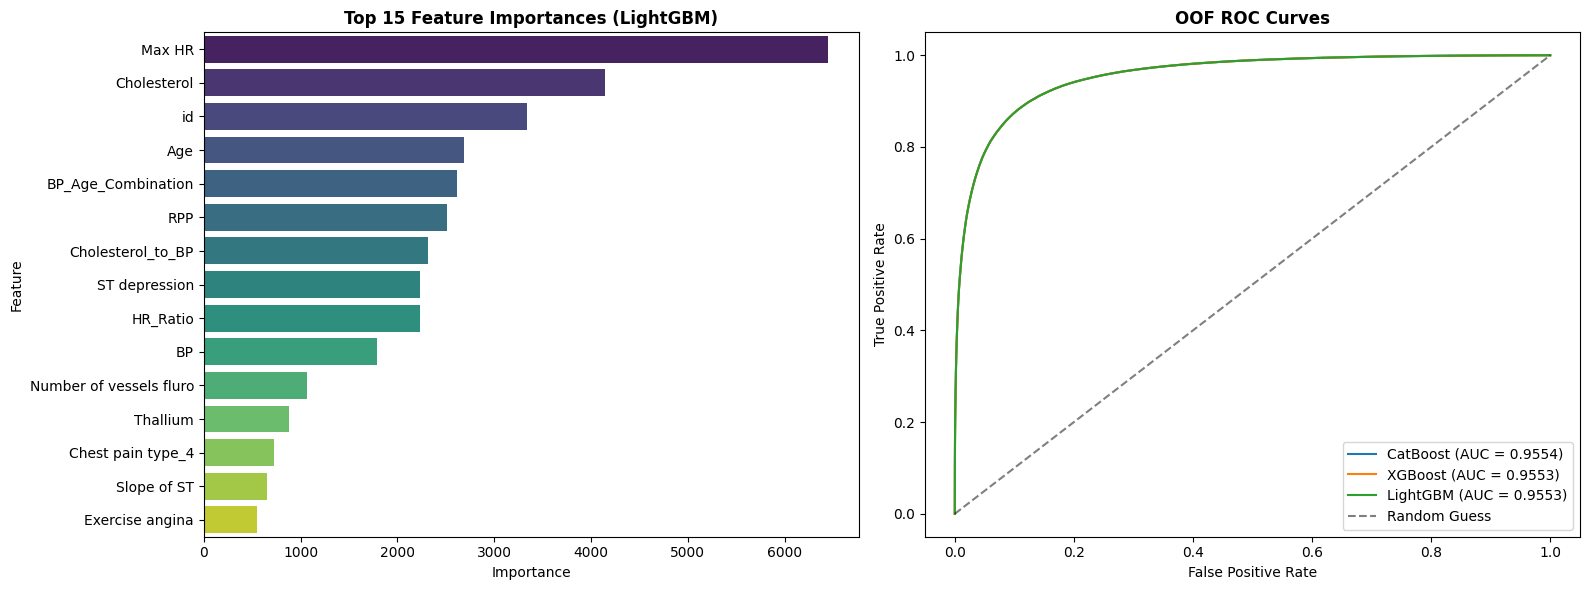

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Feature Importances (Top 15)
importances_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_importances
}).sort_values(by='Importance', ascending=False).head(15)

sns.barplot(data=importances_df, x='Importance', y='Feature', ax=ax[0], palette='viridis')
ax[0].set_title("Top 15 Feature Importances (LightGBM)", fontweight='bold')

# Plot 2: ROC Curves
fpr_cb, tpr_cb, _ = roc_curve(y_train, oof_cb)
fpr_xgb, tpr_xgb, _ = roc_curve(y_train, oof_xgb)
fpr_lgb, tpr_lgb, _ = roc_curve(y_train, oof_lgb)

ax[1].plot(fpr_cb, tpr_cb, label=f'CatBoost (AUC = {roc_auc_score(y_train, oof_cb):.4f})')
ax[1].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_train, oof_xgb):.4f})')
ax[1].plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {roc_auc_score(y_train, oof_lgb):.4f})')
ax[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Guess')

ax[1].set_title("OOF ROC Curves", fontweight='bold')
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [20]:
print("\nTraining Meta-Model (Logistic Regression)...")
# Using Rankdata for stacking limits scale issues
train_stack = np.column_stack([
    rankdata(oof_cb) / len(oof_cb),
    rankdata(oof_xgb) / len(oof_xgb),
    rankdata(oof_lgb) / len(oof_lgb)
])

test_stack = np.column_stack([
    rankdata(test_cb) / len(test_cb),
    rankdata(test_xgb) / len(test_xgb),
    rankdata(test_lgb) / len(test_lgb)
])

# Meta model
meta_model = LogisticRegression(C=1.0, random_state=42, n_jobs=-1)
meta_model.fit(train_stack, y_train)

oof_final = meta_model.predict_proba(train_stack)[:, 1]
test_final = meta_model.predict_proba(test_stack)[:, 1]

predict = meta_model.predict(test_stack)

print(f"\n🚀 FINAL STACKED CV AUC: {roc_auc_score(y_train, oof_final):.5f}")


Training Meta-Model (Logistic Regression)...

🚀 FINAL STACKED CV AUC: 0.95540


In [22]:
submission = pd.DataFrame({
    "id": test_fe['id'],
    'Heart Disease': predict
})

submission.to_csv("submission.csv", index=False)
print("\nSUBMISSION SAVED: 'submission.csv'")


SUBMISSION SAVED: 'submission.csv'
